# Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms

In this document, we are replicating the work by S.Sim,P.D.Johnson and A.Aspuru-Guzik *Adv.Quantum.Technol.* **2** 1900070 (2019): https://arxiv.org/abs/1905.10876

Consider a parameterized quantum circuit $U(\mathbf{x})$, and define the quantity
$$f(\mathbf{x},\mathbf{y}) = |\langle 0 | U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}$$
This quantity is the fidelity of the two states
$$\begin{align*}
|\psi_{\mathbf{x}}\rangle = U(\mathbf{x})|0\rangle~~&\text{and}~~|\psi_{\mathbf{y}}\rangle = U(\mathbf{y})|0\rangle:\\
|\langle \psi_{\mathbf{y}}|\psi_{\mathbf{x}}\rangle|^{2} &= |\langle 0 |U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}.
\end{align*}$$

Suppose we generate a bunch of random realizations of $\mathbf{x},\mathbf{y}$. This gives us a set of random realizations of $f$; let's call that set $F = \{f_{1}, f_{2}, \cdots \}$.

To calculate the expressibility, we need to do 2 things:
* Generate a _histogram_ of the elements of $F$. The output of this histogram is a set of bins $B = \{(l_1, u_1), (l_2, u_2), \cdots \}$ where $l_{j}$ ($u_j$) denotes the lower (upper) limit of bin $j$. It also produces an empirical probability distribution function $\mathrm{Pr}_{\text{emp}}(j)$, which is simply the probability that a given value of $f$ falls in a bin $j$.
* Given the bins of the histogram, we need to compute the probability that a given fidelity value would fall into bin $j$ if the circuit generating that fidelity is drawn from a Haar-random distribution. If the circuit acts on $n$ qubits, the probability of a given fidelity value $f$ is:
$$ \mathrm{Pr}_{\text{Haar}}(f) = (N -1)*(1-f)^{N-2}~~N=2^{n}.$$
To calculate the probability over a bin of the histogram, we do an integral:
$$\mathrm{Pr}_{\text{Haar}}(j) = \int_{l_{j}}^{u_{j}}  \mathrm{Pr}_{\text{Haar}}(f) ~df =  (1-l_{j})^{N-1}  - (1-u_{j})^{N-1}$$
The expressibility is then estimated as the KL divergence between the empirically-observed probability distribution (i.e., the histogram) and the probability distribution that would result under a Haar-random unitary.
$$\text{Expr} = \mathrm{KL}(\mathrm{Pr}_{\text{emp}}|| \mathrm{Pr}_{\text{Haar}}) = \sum_{j} \mathrm{Pr}_{\text{emp}}(j)\log\left(\frac{\mathrm{Pr}_{\text{emp}}(j)}{\mathrm{Pr}_{\text{Haar}}(j)}\right)$$

## Imports

In [1]:
import os

import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister, Gate, Measure
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

from math import pi, sqrt

from scipy.special import rel_entr
from scipy.stats import entropy
from scipy.special import kl_div, rel_entr
from random import seed
from random import random,choice
import random
import cmath

## IQC

### NF2

In [2]:
MODEL='IQC'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Circuito Exemplo _Parameters_

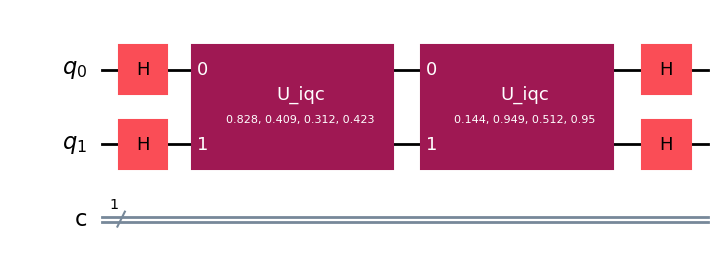

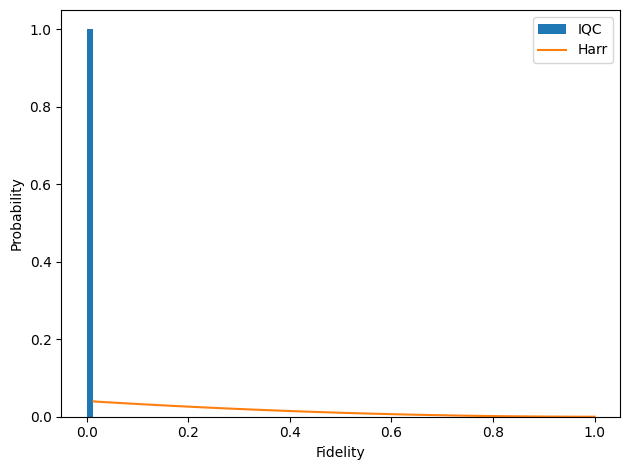

In [3]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]

params=tx+tw
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    '''
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


#### Sem objeto _Parameters_

┌───┐┌──────────┐┌──────────┐┌───┐
q_0: ┤ H ├┤0         ├┤0         ├┤ H ├
     ├───┤│  Unitary ││  Unitary │├───┤
q_1: ┤ H ├┤1         ├┤1         ├┤ H ├
     └───┘└──────────┘└──────────┘└───┘

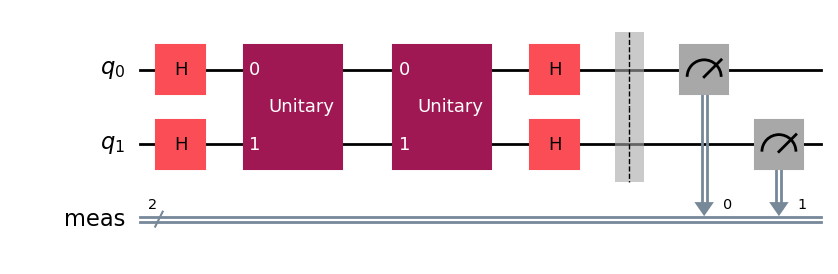

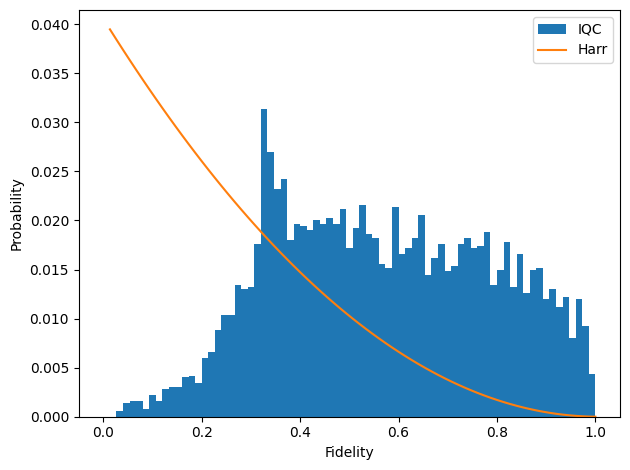

In [5]:
fidelity=[]    
for dd in range(simulation_samples):
    tx = rng.random((2,NF))  # Parâmetros para tx
    tw = rng2.random((2,NF))  # Parâmetros para tw
    #qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw[0],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
    qc=QuantumCircuit(N_qubits)
    
    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt)
    U2, X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt)
    
    qc.h(qubits)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    qc.h(qubits)
    if dd==0:
        display(qc.draw())
    
    count=run_qasm_counts_meas_all(qc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

##### Quantitative Analysis

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 1.188 nats
S(P || Q): 1.188 nats
KL(P || Q): 1.188 nats


### NF4

In [7]:
MODEL='IQC'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

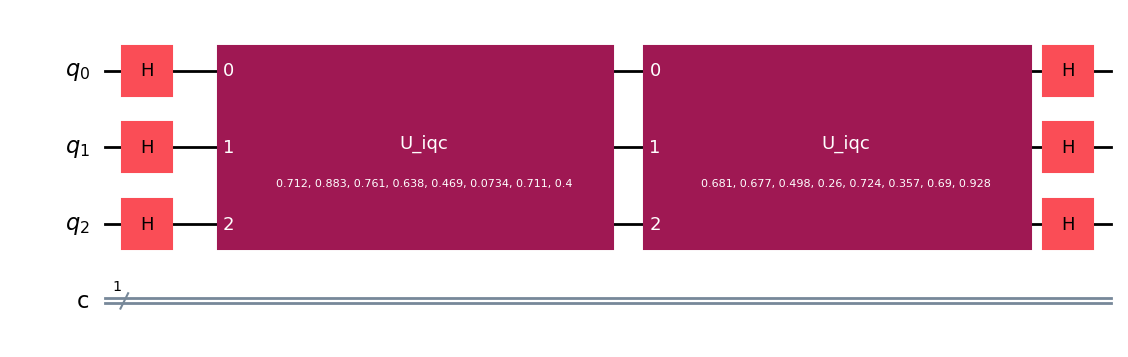

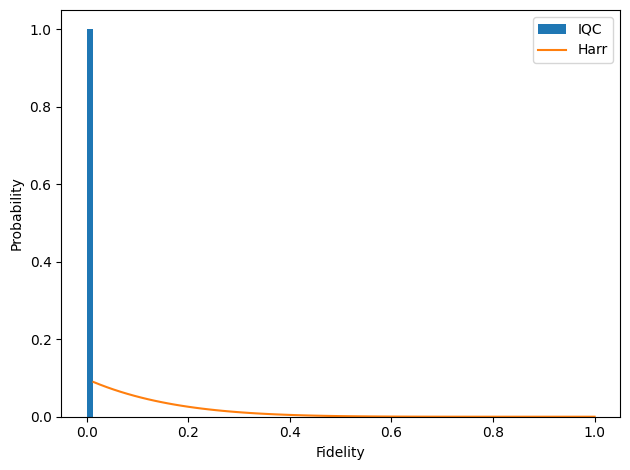

In [8]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]

params=tx+tw
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


## IQC_AIL

### NF2

In [10]:
MODEL='IQC_AIL'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

#### Sem obj _Parameters_

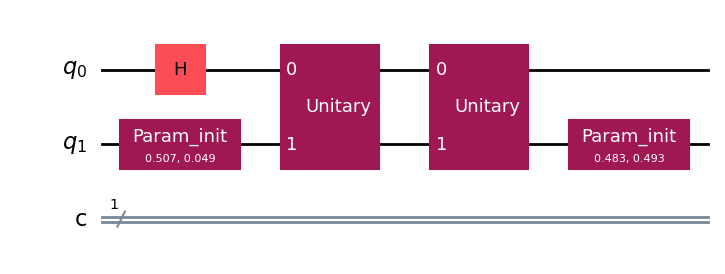

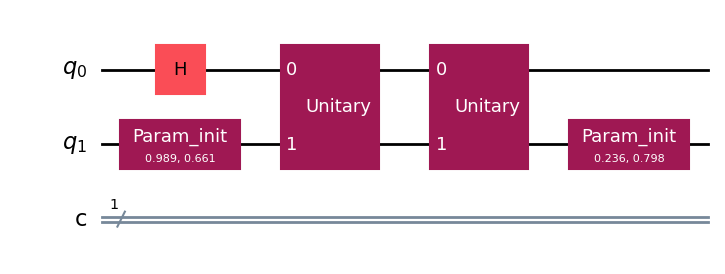

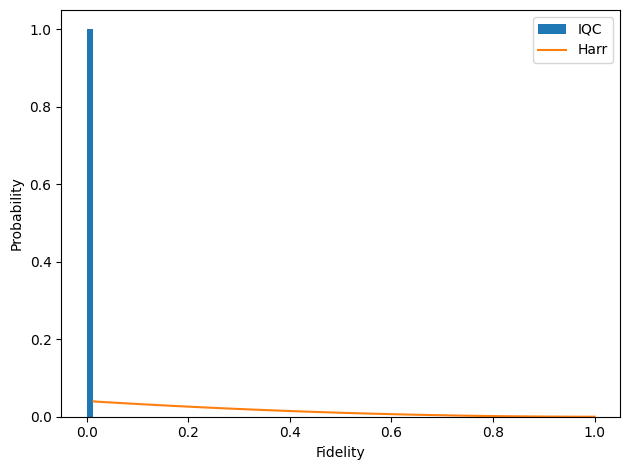

In [11]:
class ParamInitializeGate(Gate):
    def __init__(self, num_qubits, params, N_features):
        super().__init__("param_init", num_qubits, params)
        self.N_features = N_features
        
    def _define(self):
        q = QuantumRegister(self.num_qubits)
        qc = QuantumCircuit(q)
        
        # Convert parameters to normalized state vector
        params = np.array(self.params, dtype=complex)
        norm = np.linalg.norm(params)
        if norm > 0:
            params = params/norm
            
        qc.initialize(params, q[:])
        self.definition = qc

fidelity=[]    
for dd in range(simulation_samples):
    tx = rng.random((2,NF))  # Parâmetros para tx
    tw = rng2.random((2,NF))  # Parâmetros para tw
    
    qc=QuantumCircuit(N_qubits, N_qubits_tgt)
    
    init_gate1 = ParamInitializeGate(N_qubits-1, tx[0], N_features=NF)
    qc.append(init_gate1, range(1,N_qubits))
    qc.h(0)

    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt,iqcail=True)
    U2, X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt, iqcail=True)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    init_gate2 = ParamInitializeGate(N_qubits-1, tx[1], N_features=NF)
    qc.append(init_gate2, range(1,N_qubits))
    if dd==0:
        display(qc.draw('mpl'))
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


#### Com obj _Parameters_

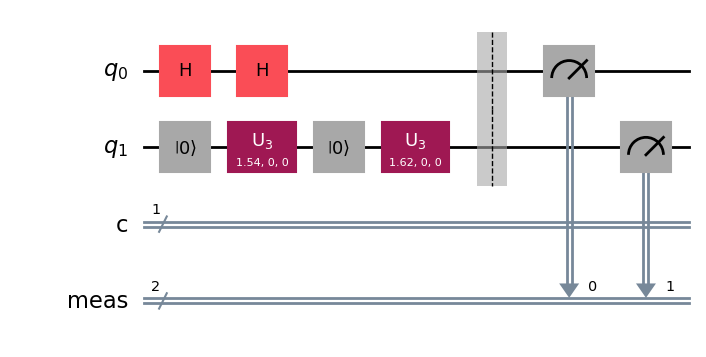

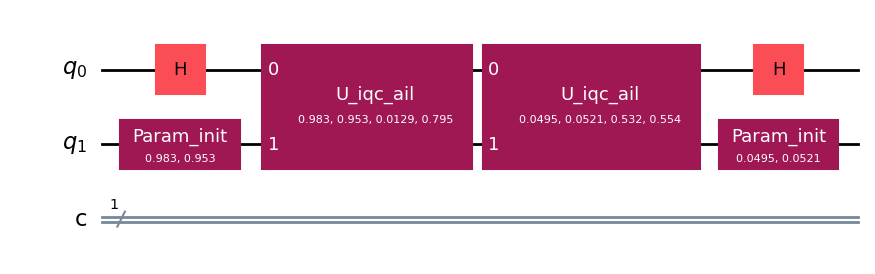

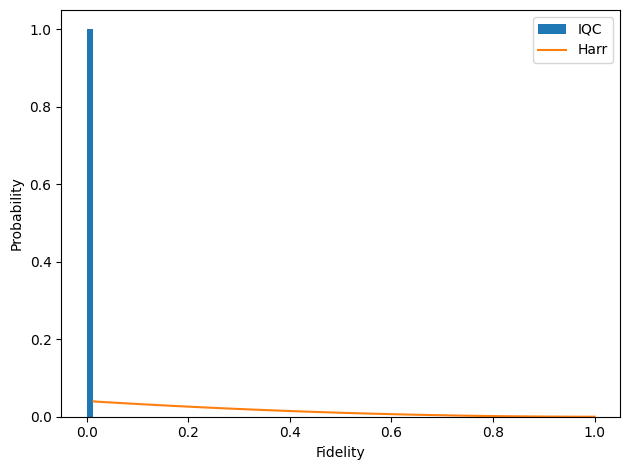

In [13]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(tqc.draw('mpl'))

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


### NF4

In [15]:
MODEL='IQC_AIL'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

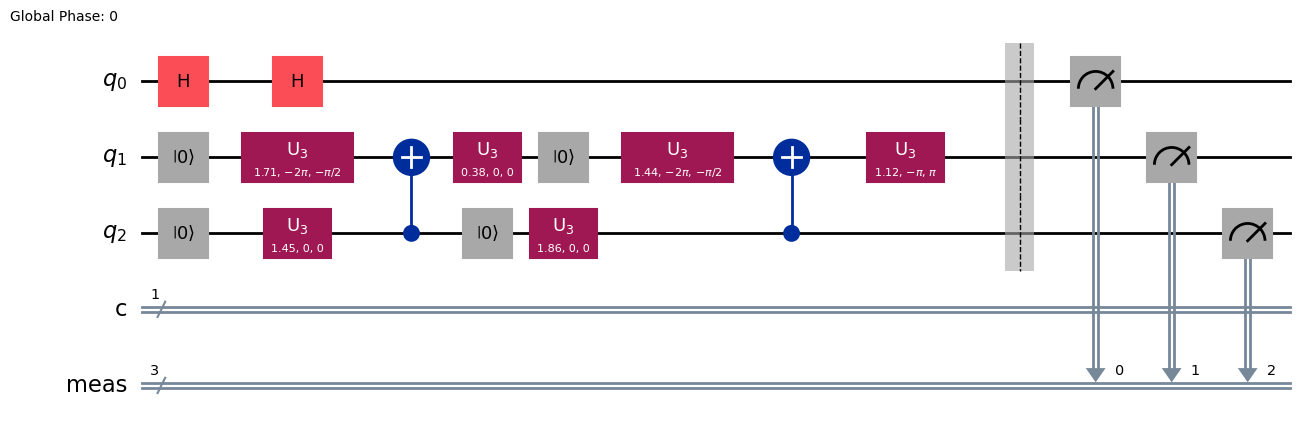

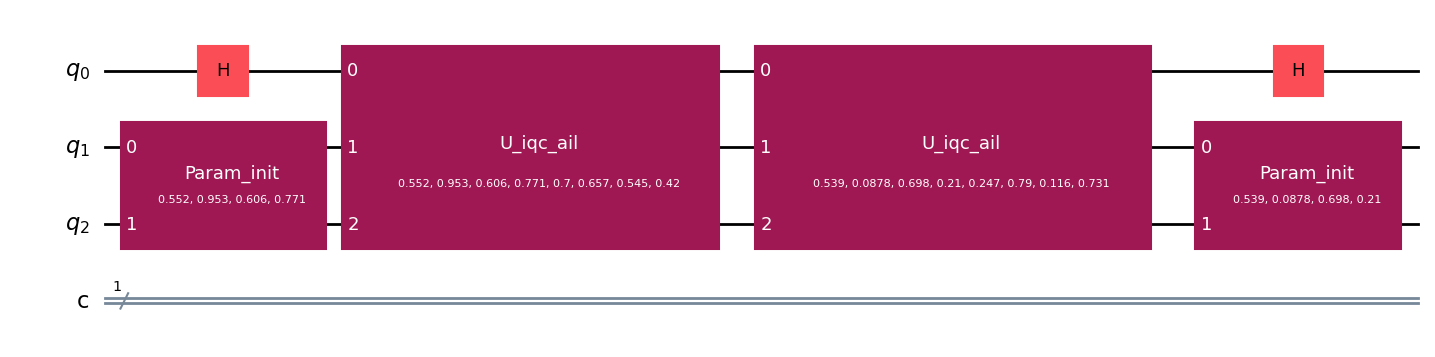

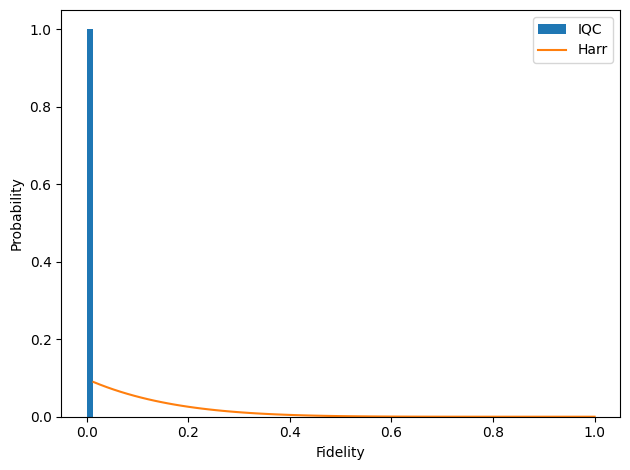

In [16]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(tqc.draw('mpl'))

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


## IQCpQ, N_qubits_tgt=2

### NF2

In [18]:
MODEL='IQCpQ'
NF=2
N_qubits_tgt=2
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

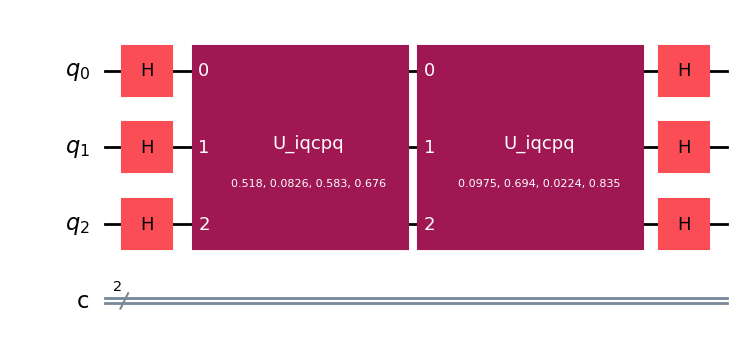

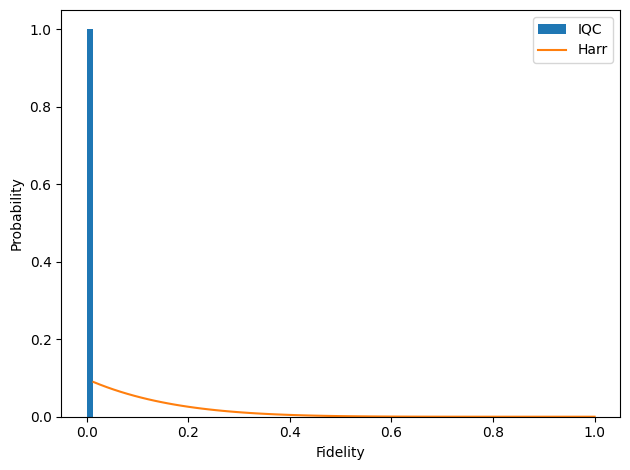

In [19]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


#### Sem obj _Parameters_

┌───┐┌──────────┐┌──────────┐┌───┐
q_0: ┤ H ├┤0         ├┤0         ├┤ H ├
     ├───┤│          ││          │├───┤
q_1: ┤ H ├┤1 Unitary ├┤1 Unitary ├┤ H ├
     ├───┤│          ││          │├───┤
q_2: ┤ H ├┤2         ├┤2         ├┤ H ├
     └───┘└──────────┘└──────────┘└───┘
c: 2/══════════════════════════════════

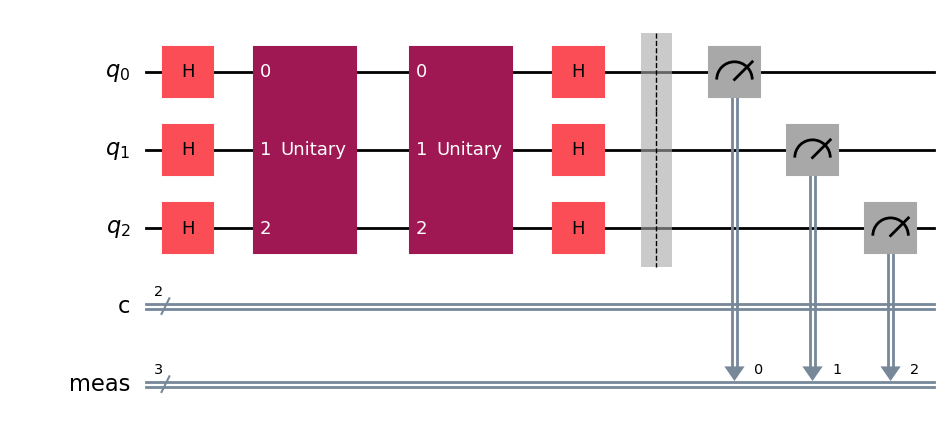

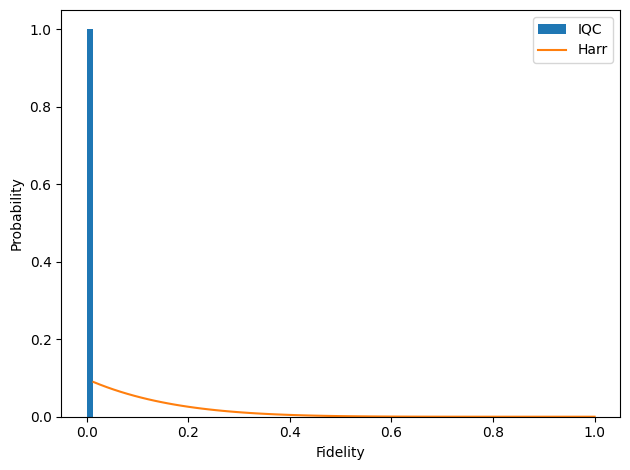

In [21]:
tx = rng.random((2,NF))  # Parâmetros para tx
tw = rng2.random((2,NF))  # Parâmetros para tw


fidelity=[]    
for dd in range(simulation_samples):
    #qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw[0],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
    qc=QuantumCircuit(N_qubits, N_qubits_tgt)
    
    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt)
    U2,X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt)
    
    qc.h(qubits)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    qc.h(qubits)
    if dd==0:
        display(qc.draw())
    
    count=run_qasm_counts_meas_all(qc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


### NF4

In [23]:
MODEL='IQCpQ'
NF=4
N_qubits_tgt=2
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

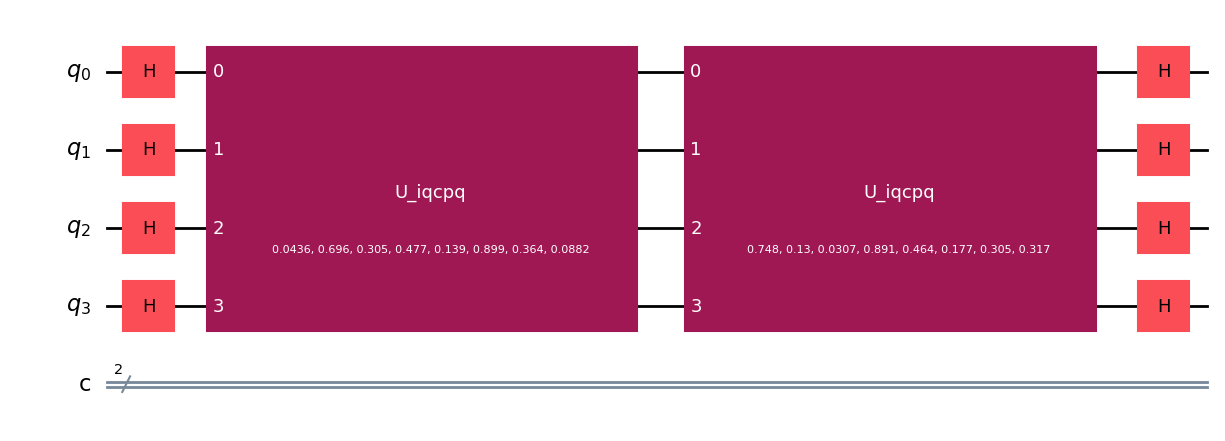

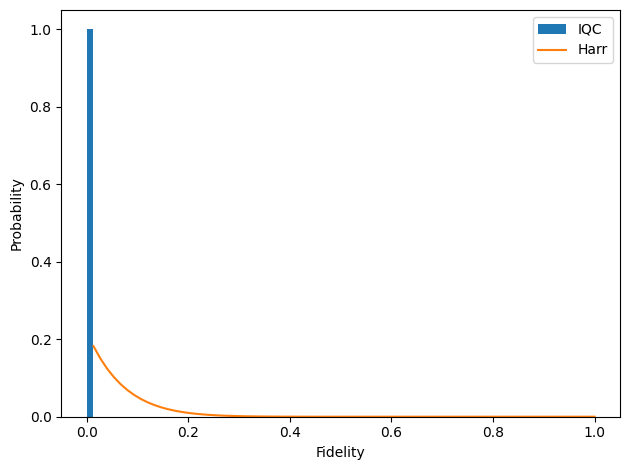

In [24]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 1.702 nats
S(P || Q): 1.702 nats
KL(P || Q): 1.702 nats


## IQCpQ, N_qubits_tgt=4

### NF2

In [26]:
MODEL='IQCpQ'
NF=2
N_qubits_tgt=4
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

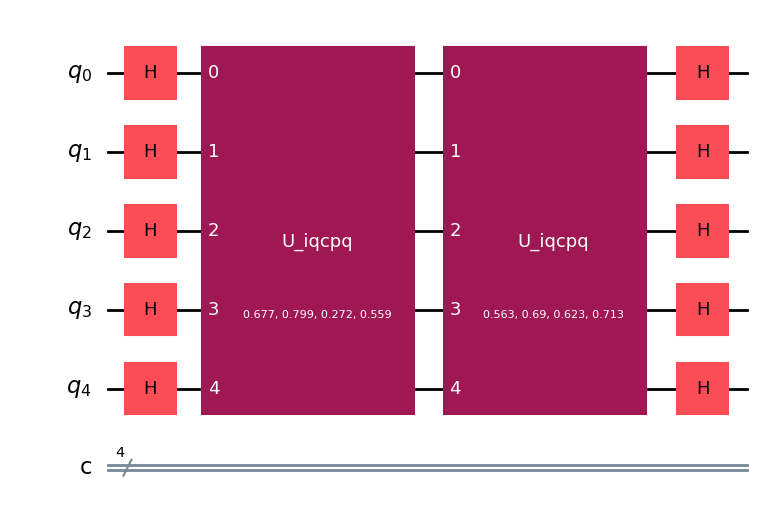

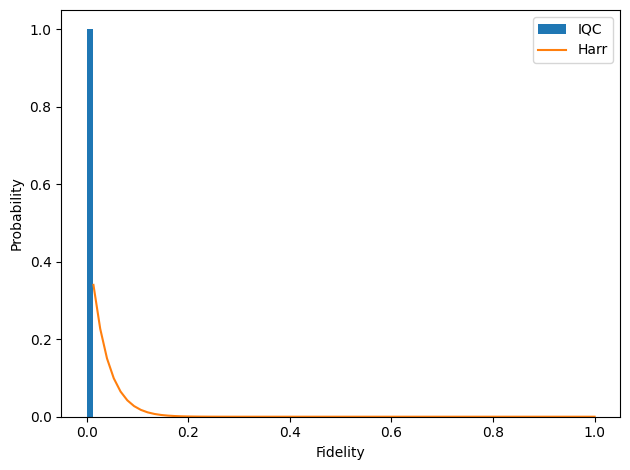

In [27]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 1.078 nats
S(P || Q): 1.078 nats
KL(P || Q): 1.078 nats


### NF4

In [29]:
MODEL='IQCpQ'
NF=4
N_qubits_tgt=4
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

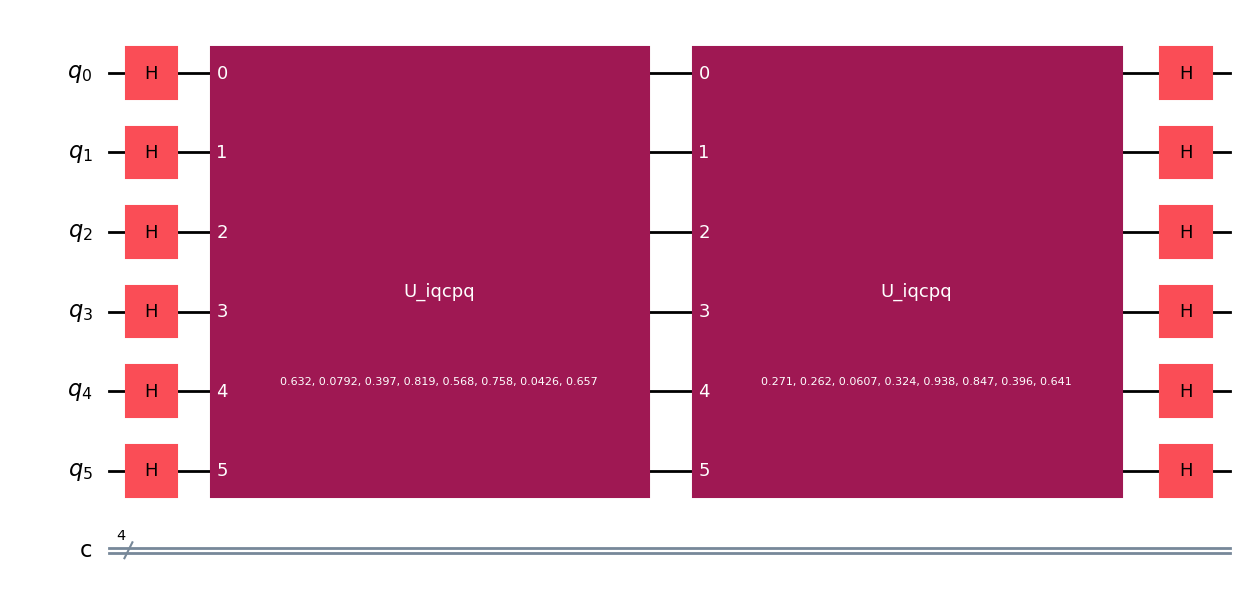

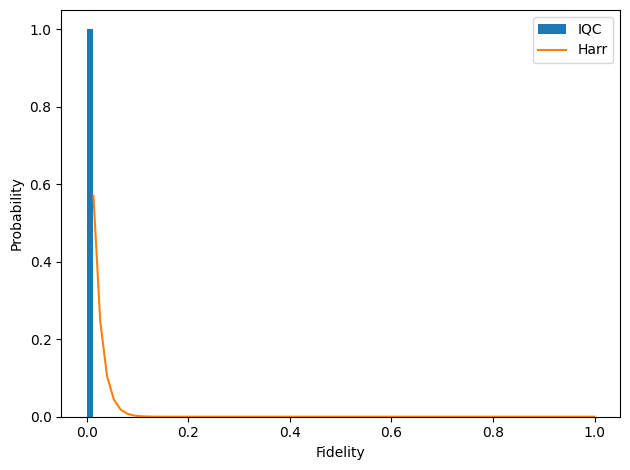

In [30]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 0.561 nats
S(P || Q): 0.561 nats
KL(P || Q): 0.561 nats


## IQCNDsE

### NF2

In [32]:
MODEL='IQCNDsE'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

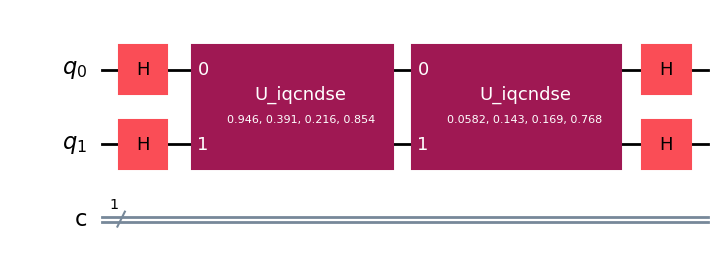

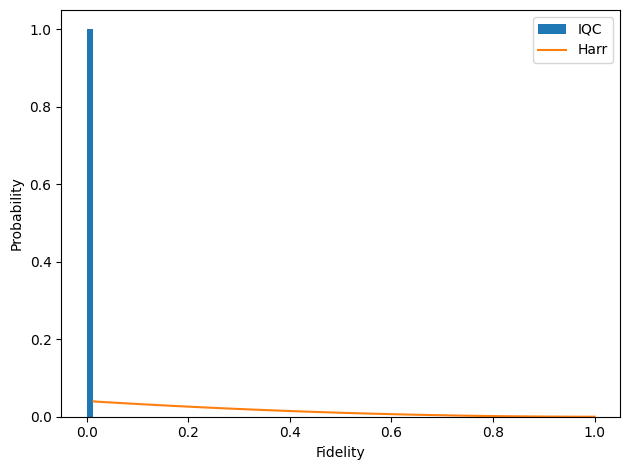

In [33]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)


aa={}
fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    aa=param_binding
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


### NF4

In [35]:
MODEL='IQCNDsE'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

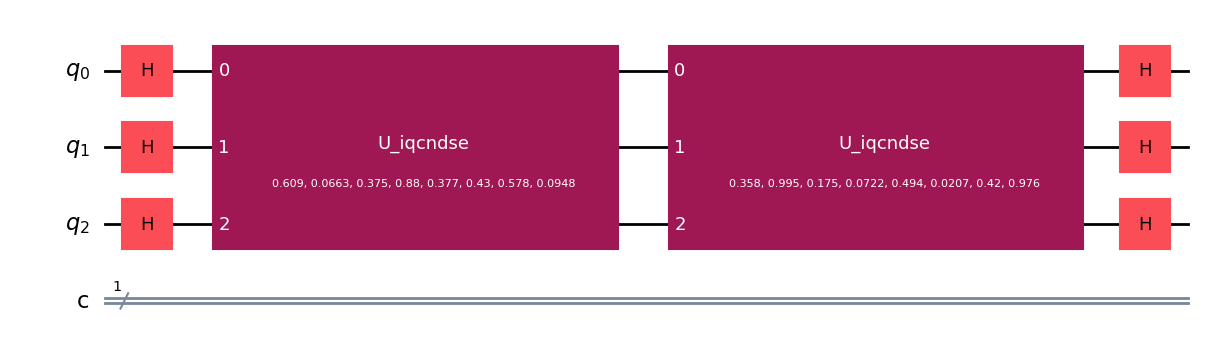

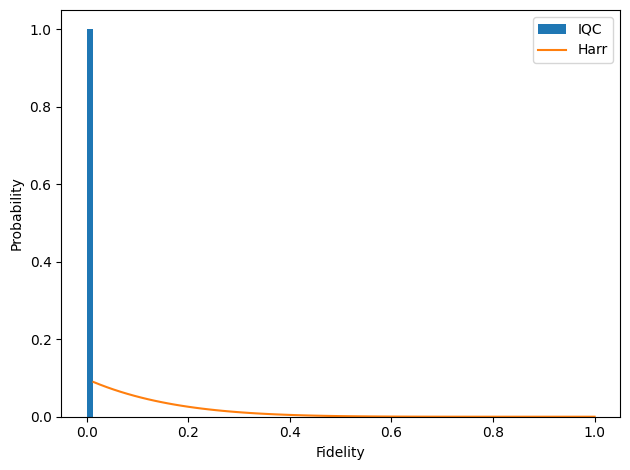

In [36]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)


aa={}
fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    aa=param_binding
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


## IQC_Angle

### NF2

In [2]:
MODEL='IQC_Angle'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

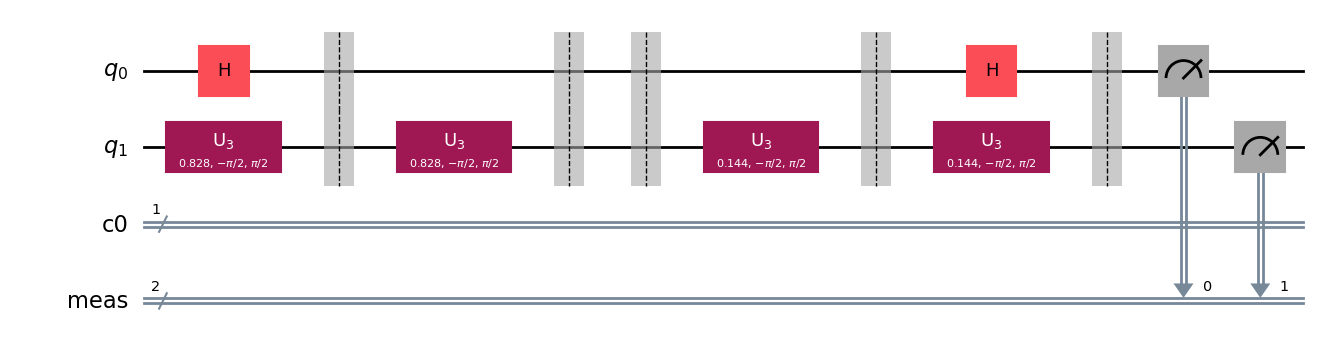

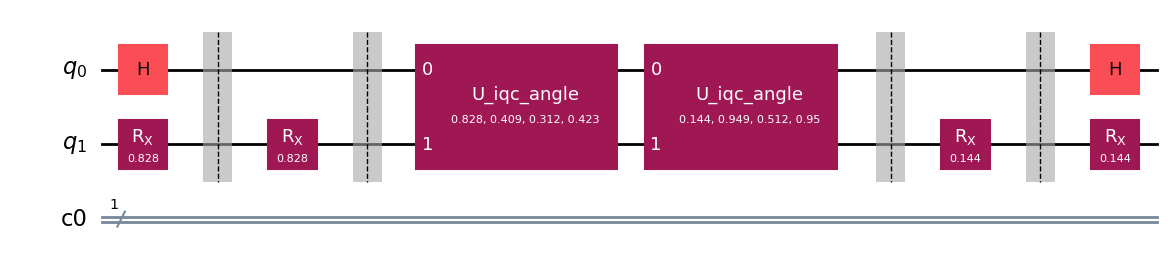

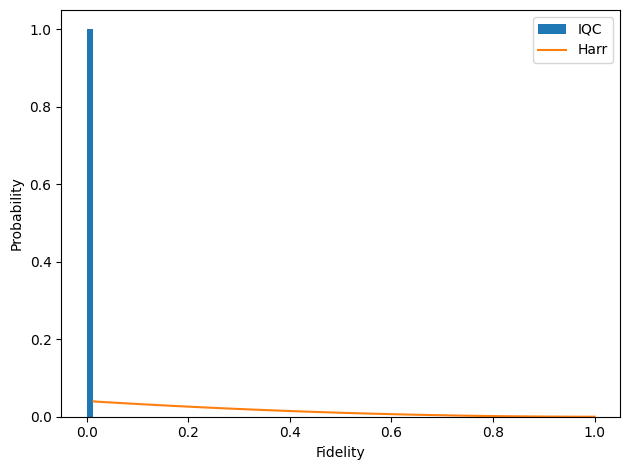

In [3]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw

#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)

fidelity=[]    
for _ in range(2000):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(tqc.draw('mpl'))

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


### NF4

In [ ]:
MODEL='IQC_Angle'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000


In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)

fidelity=[]    
for _ in range(2000):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


### NF8

In [11]:
MODEL='IQC_Angle'
NF=16
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000


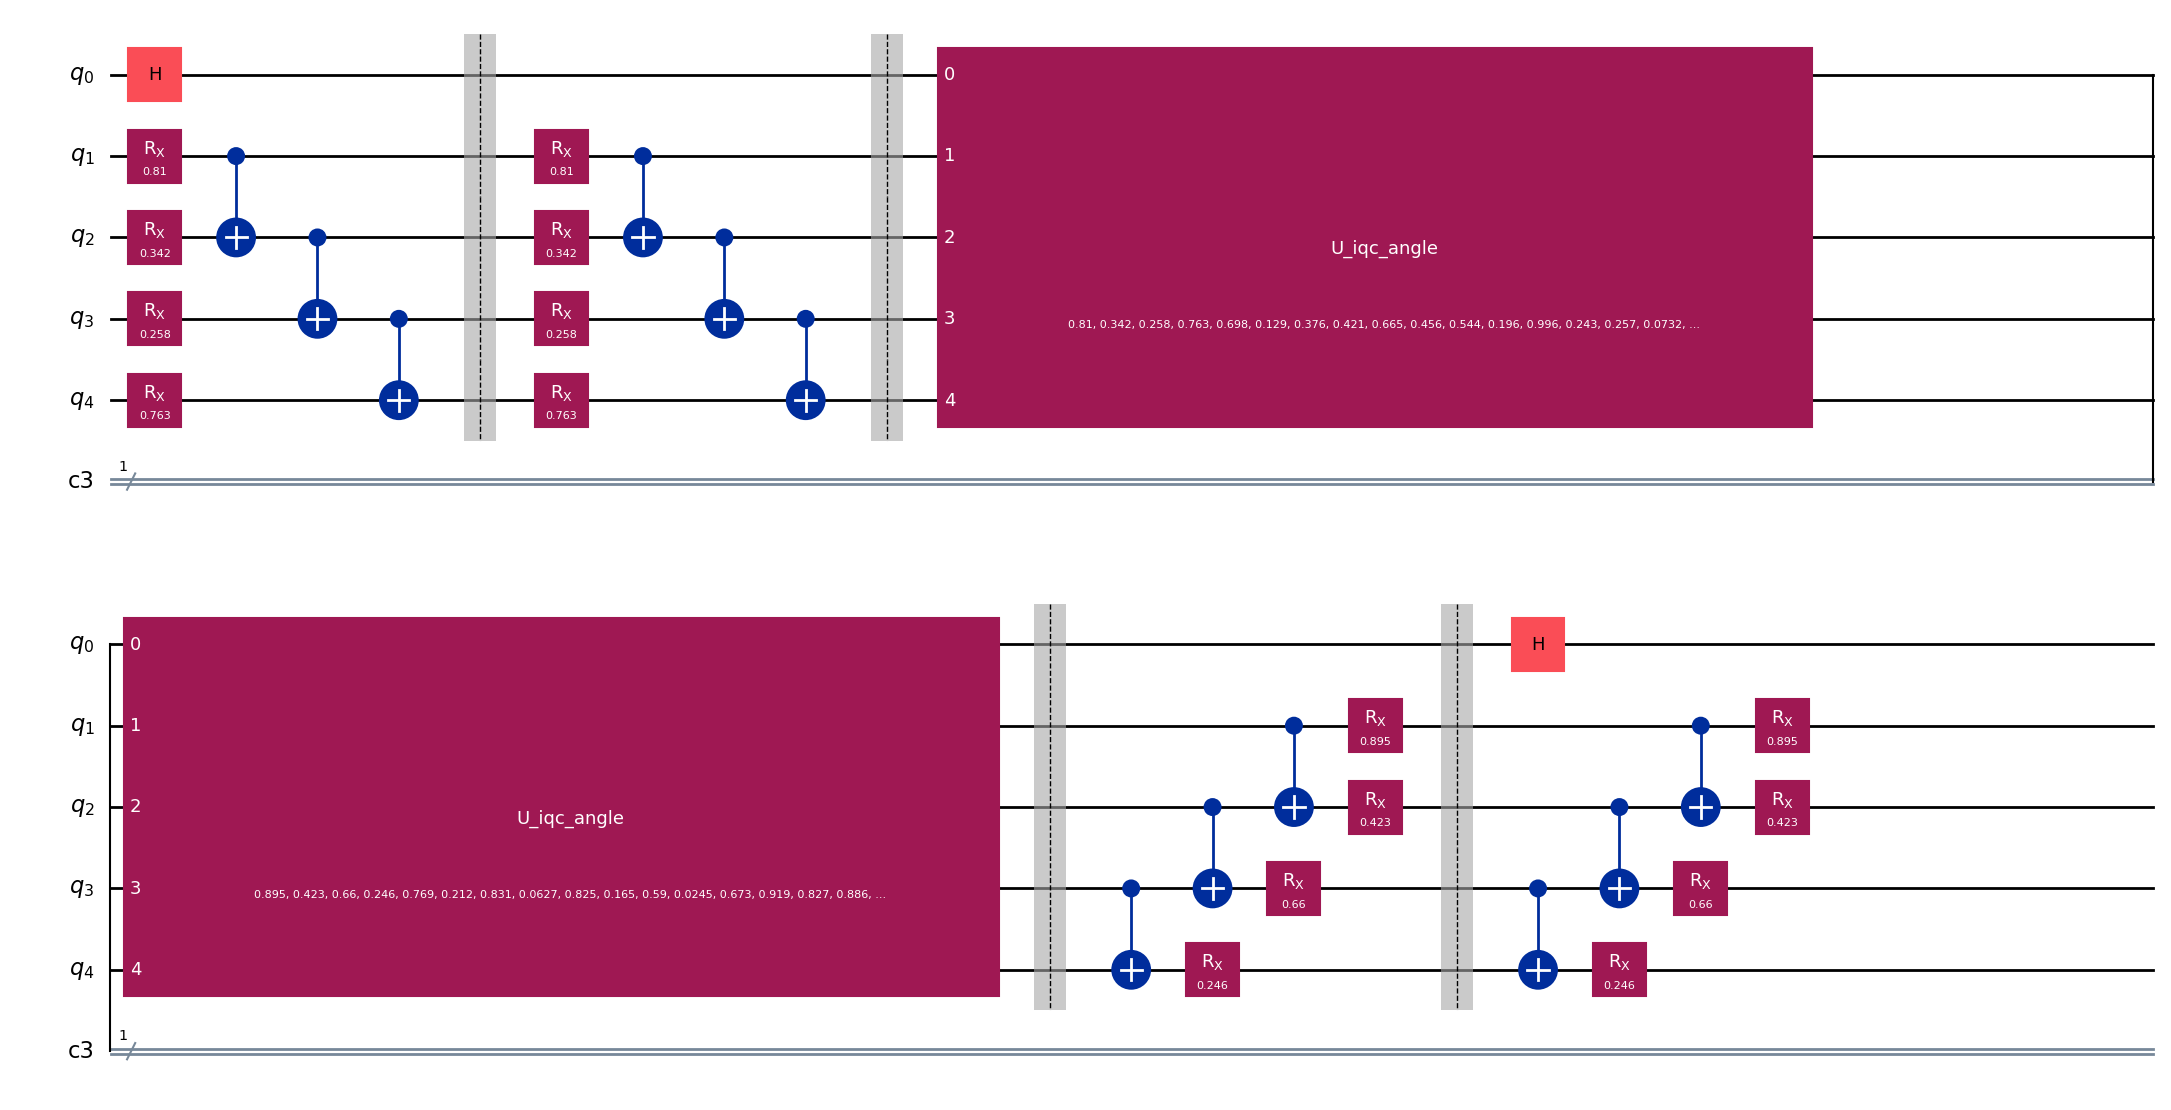

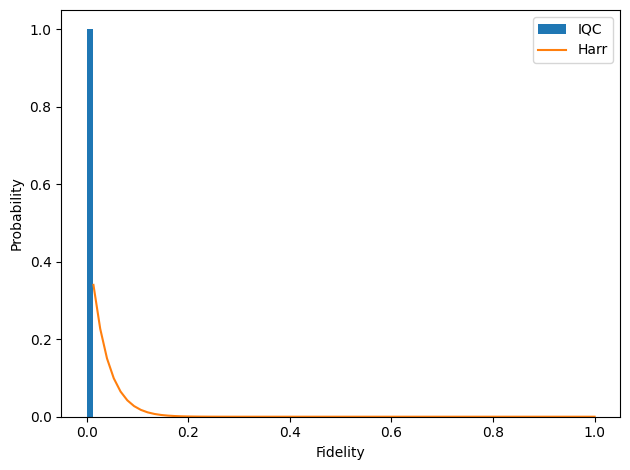

In [12]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)

fidelity=[]    
for _ in range(2000):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_all_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()


In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q)= %.3f' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q)= %.3f' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q)= %.3f' %sum(kl_pq))

rel_entry(P || Q): 1.078 nats
S(P || Q): 1.078 nats
KL(P || Q): 1.078 nats
